In [132]:

import pandas as pd
import numpy as np
from pandas_datareader.data import DataReader
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import statsmodels.api as sm
import sys
import os
sys.path.append(os.path.abspath(".."))

---
# Moving Average Price options-Inspired Residual Trading Strategy

## Inspiration

This strategy is inspired by the payoff structure of **moving average price options**.

Unlike standard European options, they depend on the **moving average of price** of the underlying asset over a given period, rather than only on its terminal price.

This suggests that the moving-average returns can be interpreted as a form of **synthetic underlying asset**, theoretically replicable through synthetic forward positions.

The Agent Based Model proposed by **<span style="color: #2e6f40;">Taisei Kaizoji</span>** ([see reference](https://www.sciencedirect.com/science/article/abs/pii/S0378437100003885?via%3Dihub)) in 2000 was proved to exhibit strong predictions capabilities for smoothed returns(see my previous notebook). The strategy use that particular caracteristic of that model to generate signals

---
## Presentation of the strategy

The strategy is applied to residuals obtained from **Principal Component Analysis (PCA)** of a portfolio of 30+ cryptocurrencies.

PCA is used to extract the dominant common components driving the cross-section of assets. The residuals represent then the idiosyncratic component of the returns.

We then using the ABM model to predict the direction of the next residual and create signal. 

This allows the strategy to exploit temporary imbalances in the residual component

---

## Procedure

The procedure of this **short-horizon residual trading strategy** is:

1. computing PCA residuals and auxiliary series on a walkforward basis;
2. use the ABM model to forecast next residuals;
3. exploit the anticorrelation between actual and forecasted residuals to generate signal;
4. compute the premium cost for synthetic asset as transactionnal costs;

---

#### References
* Kaizoji, T. (2006). An interacting-agent model of financial markets from the viewpoint of nonextensive statistical mechanics. *Physica A: Statistical Mechanics and its Applications*, 370(1), 109-113. Available via [Elsevier / ScienceDirect](https://www.sciencedirect.com/science/article/abs/pii/S0378437100003885?via%3Dihub).

In [133]:

# ============================================================
# Step 1 - Data Cleaning and Preprocessing
# ============================================================

# importing the crypto ohcl datas
crypto_ohcl_df = pd.read_pickle('../data/crypto_ohlc.pkl')

# removing all the the non pertinent cryptoasset
crypto_ohcl_df=crypto_ohcl_df.drop(columns=['USDC'], level=0)
coins = crypto_ohcl_df.columns.get_level_values(0)
cols_removed=coins.str.endswith(("UP","DOWN","USD"))
crypto_ohcl_df = crypto_ohcl_df.loc[:,~cols_removed]

# rearanging the dataset
crypto_ohcl_df=crypto_ohcl_df.stack(level=0,future_stack=False).reset_index().rename(columns={"level_1":"crypto"})
crypto_ohcl_df=crypto_ohcl_df.set_index(["crypto", "date"]).sort_index()

# removing the crypto with less than 80% of the btc datapoints  
counts = crypto_ohcl_df.groupby('crypto').size()
vaild_crypto = counts[counts>=0.95*(crypto_ohcl_df.loc['BTC'].shape[0])]
crypto_ohcl_df = crypto_ohcl_df.loc[vaild_crypto.index]



In [134]:
# ============================================================
# Step 2 - Defining the importants features
# ============================================================

#computing the raw_returns
for crypto in vaild_crypto.index:
    crypto_ohcl_df.loc[(crypto,slice(None)),'returns'] = (crypto_ohcl_df.loc[(crypto,slice(None)),'close']/crypto_ohcl_df.loc[(crypto,slice(None)),'close'].shift() -1).fillna(0)

crypto_df = crypto_ohcl_df.replace([np.inf, -np.inf], np.nan).dropna()
raw_returns = crypto_df['returns'].unstack('crypto')
price=crypto_df['close'].unstack('crypto')

#computing moving average returns
returns=raw_returns.dropna()
returns = returns.rolling(10).mean().dropna()
rets = returns.copy()

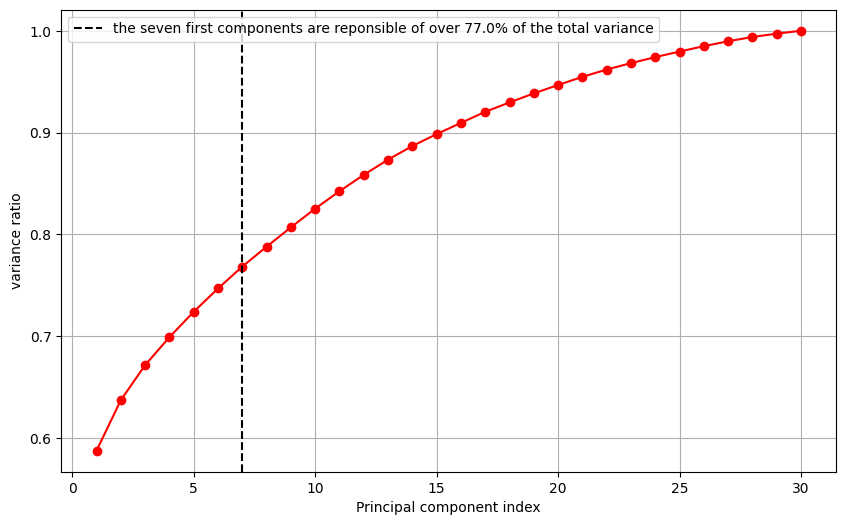

In [135]:
# ============================================================
# Step 3 - Analyzing the explained variance via PCA
# ============================================================

scaler = StandardScaler()
returns_scaled = scaler.fit_transform(returns)
pca= PCA()
pca_components = pca.fit_transform(returns_scaled)
df_PCA = pd.DataFrame(data=pca_components, index=returns.index,columns=[f'PCA {i+1}'for i in range(len(returns.columns))]) 

plt.figure(figsize=(10,6))
X = np.arange(1,len(pca.explained_variance_ratio_)+1,1)
Y = pca.explained_variance_ratio_.cumsum()
plt.plot(X,Y,'ro-')
plt.xlabel('Principal component index')
plt.ylabel('variance ratio')
plt.grid()
plt.axvline(x=7,linestyle='--',color="black", label=f"the seven first components are reponsible of over {np.ceil(Y[6]*100)}% of the total variance")
plt.legend()
plt.show()

In [136]:
# =====================================================================================================
# Step 4 - Visualisation of the variance of principal components on a rolling window 
# =====================================================================================================


window = 252
scaler = StandardScaler()
rolling_pca=[]

# constucting the rolling explained variance for all components
for i in range (window, len(returns.index)):
    returns_sample = returns.iloc[i-window:i,:]
    returns_sample_scaled = scaler.fit_transform(returns_sample)
    pca_window = PCA()
    pca_components = pca_window.fit_transform(returns_sample_scaled)
    rolling_pca.append(pca_window.explained_variance_ratio_)

rolling_pca_df = pd.DataFrame(rolling_pca, index=returns.index[window:], columns=[f'PCA{i+1}'for i in range (len(returns.columns))])


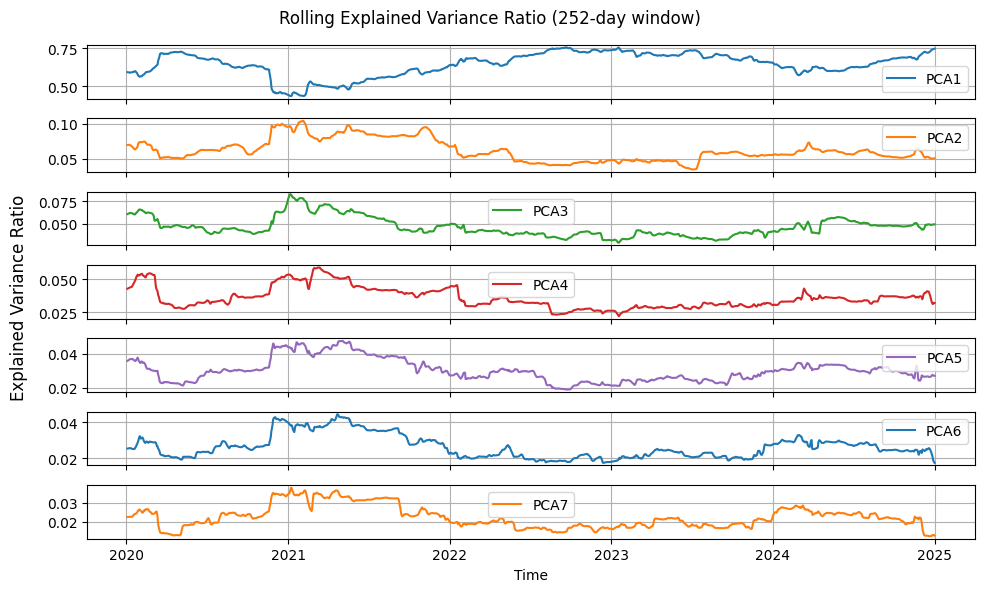

In [137]:

#selecting the first 7 residuals
cols = rolling_pca_df.columns[:7]


# plotting
fig, axes = plt.subplots(len(cols), 1, sharex=True, figsize=(10, 6))

colors = [
    'tab:blue',
    'tab:orange',
    'tab:green',
    'tab:red',
    'tab:purple'
]

size = len(rolling_pca_df)

for i, col in enumerate(cols):
    Y = rolling_pca_df.loc[:rolling_pca_df.index[size-1], col]
    X = rolling_pca_df.index[:size+1]

    axes[i].plot(X, Y, color=colors[i%len(colors)], label=col)
    #axes[i].set_ylabel('Explained Var.')
    axes[i].legend()
    axes[i].grid(True)

axes[-1].set_xlabel('Time')
fig.suptitle('Rolling Explained Variance Ratio (252-day window)')
fig.supylabel('Explained Variance Ratio')
plt.legend()
plt.tight_layout()
plt.show()

In [138]:
# =====================================================================================================
# Step 4 - Visualisation of the variance of principal components on a rolling window 
# =====================================================================================================

number_of_components = 7 # number of P.C considered for the residuals 


residuals_df=pd.DataFrame(index=returns.index, columns=returns.columns) # DataFrame containing the residuals of all coins computed on a rolling basis

# residuals computed on the first 252 days 
returns_sample = returns.iloc[0:window]
X = scaler.fit_transform(returns_sample)
pca_window = PCA(n_components=number_of_components)
pca_components = pca_window.fit_transform(X)
X_hat = pca_window.inverse_transform(pca_components)  
residuals_df.iloc[0:window] = scaler.inverse_transform( X - X_hat)

# progressive coomputatiton of the residuals with a rolling window in order to avoid lookahaed bias
for i in range(window, len(returns.index)-1):
    returns_sample = returns.iloc[i-window:i]
    X_train = scaler.fit_transform(returns_sample)
    X_test = scaler.transform(returns.iloc[[i]])

    pca_window = PCA(n_components=number_of_components)
    pca_window.fit(X_train)          # (window, 7)
    Z_test_hat = pca_window.transform(X_test)
    X_test_hat = pca_window.inverse_transform(Z_test_hat)   # (window, 41)

    # last reconstructed point of the window, back to original units
    x_hat_last = scaler.inverse_transform(X_test_hat[-1, :].reshape(1, -1)).ravel()  # (41,)

    # next-step residual
    residual_nextstep = returns.iloc[i, :].values - x_hat_last                 # (41,)
    residuals_df.iloc[i, :] = residual_nextstep

    

[]

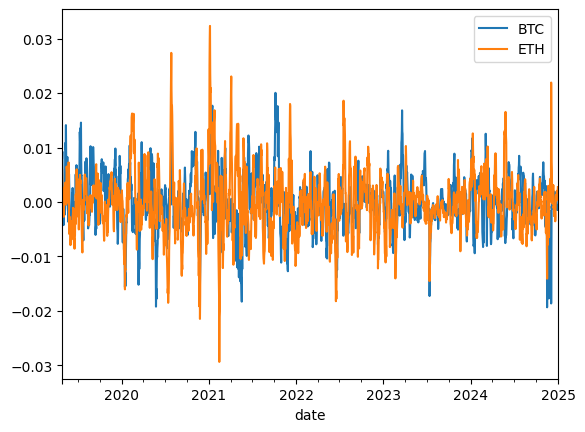

In [139]:
# plotting for reference. We can see that the resiuals are, as expected, stationnary 

residuals_df['BTC'].plot(legend='BTC')
residuals_df['ETH'].plot(legend='ETH')
plt.plot()

In [140]:
# Calculating the auxiliary_series as the cummulative sum of the residuals
aux_series_df = residuals_df.cumsum()
aux_ser_df = aux_series_df.copy()
#aux_series_df.to_pickle('../data/aux_seriesv2.pkl')

<Axes: xlabel='date'>

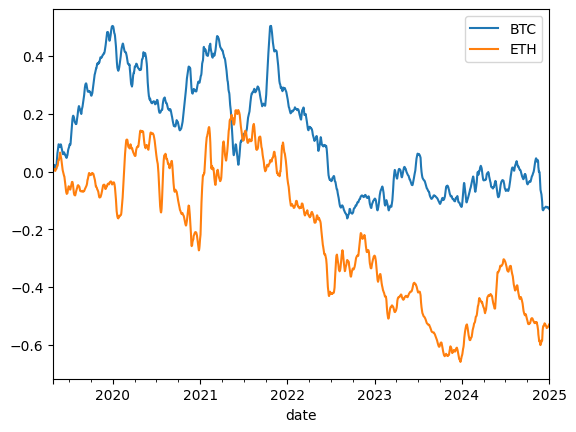

In [141]:
#Plotting for references
aux_series_df.BTC.plot(legend='BTC')
aux_series_df.ETH.plot(legend='ETH')

---
### Strategy Methodology Overview
---

#### 1. Predictive Engine Input & Output
The core engine is the predictive algorithm based on the interacting-agent based model ([Kaizoji, 2000](https://doi.org/10.1016/j.physa.2006.04.041))::
* **Inputs:** The algorithm processes a single asset's auxiliary time series (`aux_series`) over a dynamic rolling environment window.
* **Output:** It outputs a one-step-ahead predictive series (`aux_series_pred`), capturing the expected next-period value of the market indicator.

#### 2. Signal Generation via Forecast Residuals
The strategy analyzes the **expected directional change** (the forecast residual):

$$\text{Forecast Residual} = \widehat{aux}_t - aux_{t-1}$$

The expected move is ranked historically to trigger trades at statistical extremes:
* **Long Signal (+1):** Triggered when the forecast falls in the **bottom 30%** of historical data (asset is deemed oversold; expecting a bounce).
* **Short Signal (-1):** Triggered when the forecast falls in the **top 30%** of historical data (asset is deemed overbought; expecting a correction).

---

This help us to take advantage of the **anticorrelation** between the predicted and the actual residuals 

---

#### References
* Kaizoji, T. (2006). An interacting-agent model of financial markets from the viewpoint of nonextensive statistical mechanics. *Physica A: Statistical Mechanics and its Applications*, 370(1), 109-113. Available via [Elsevier / ScienceDirect](https://doi.org/10.1016/j.physa.2006.04.041).


In [142]:
end_in_sample_date = datetime(2023,12,31)
start_out_of_sample_date = datetime(2024,1,1)

in_sample_period = returns.loc[:].index
out_of_sample_period = returns.loc[start_out_of_sample_date:].index

In [143]:

import utils as ising


# =====================================================================================================
# IMPORTANT REMARK:
# Predictions are generated on a walk-forward basis to avoid look-ahead bias.
# The position calendar and the daily PnL function defined below are used instead.
# =====================================================================================================

def prediction_model(
    aux_series_df: pd.DataFrame,
    coin: str,
    normalization_window: int,
    optimisation_window: int,
    env_window: int,
):
    aux_series = aux_series_df[coin]

    results_df = ising.two_state_ising_prediction_gpu(
        aux_series,
        normalization_window,
        optimisation_window,
        env_window,
    )

    aux_series_pred = results_df["series"]

    return aux_series_pred


---
### In sample analysis
---
In this section we will examine the prediction capability of the model and prove motivation for the signal generation method.  

In [144]:

from scipy.stats import linregress

returns_is = returns.loc[in_sample_period]
aux_series_is_df = aux_series_df.loc[in_sample_period]

signals_is_df = pd.DataFrame(
    index=returns_is.index
)

pred_aux_series_is_df = pd.DataFrame(
    index=aux_series_is_df.index
)

for coin in returns.columns:
    aux_series_pred = prediction_model(
        aux_series_is_df,
        coin,
        normalization_window=10,
        optimisation_window=10,
        env_window=0,
    )

    pred_aux_series_is_df[coin] = aux_series_pred


For reference, let's start by plotting the auxiliary series and the predicted auxiliary series of BTC 

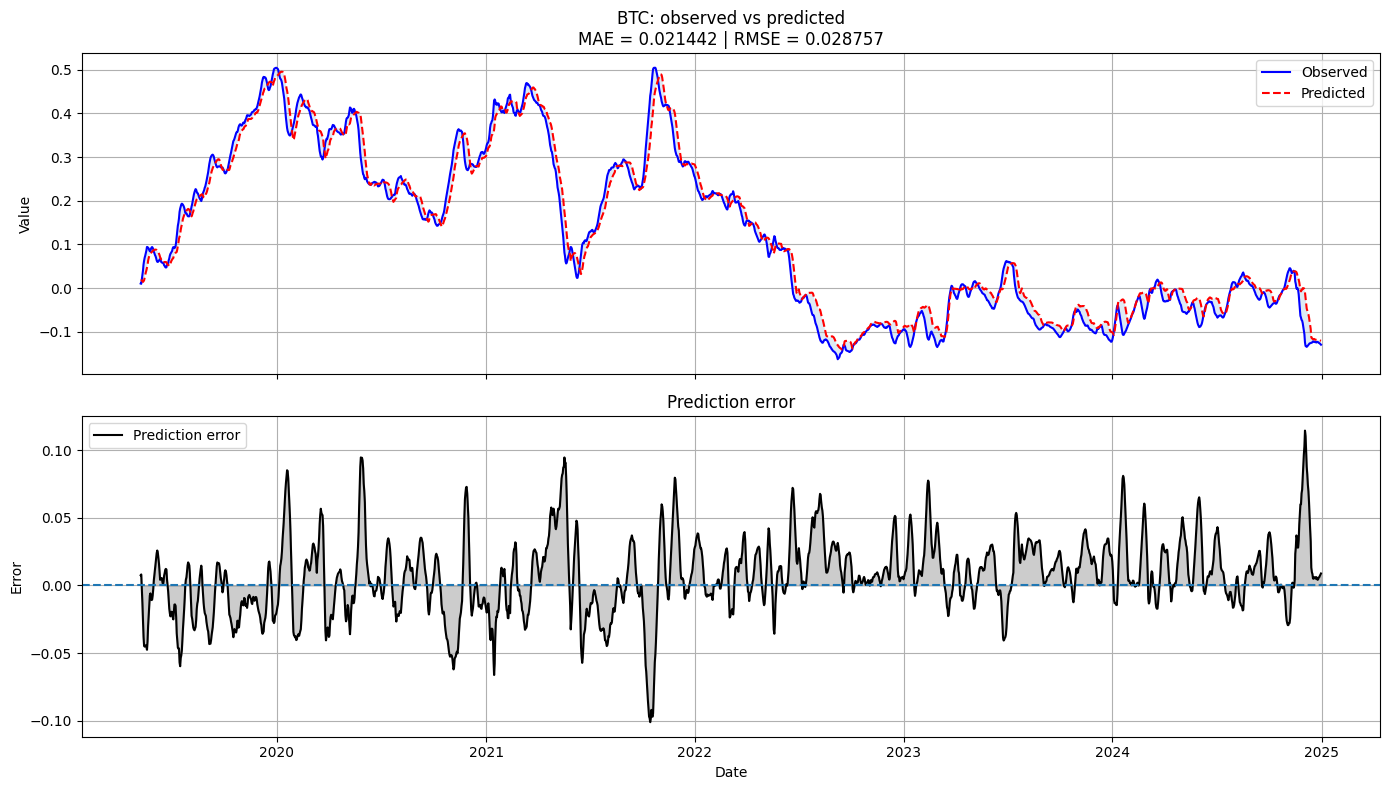

In [145]:

asset = "BTC"

def aux_series_plot(asset):
    # Alignement et nettoyage
    comparison = pd.concat(
        [
            aux_series_is_df[asset].rename("Actual"),
            pred_aux_series_is_df[asset].rename("Predicted")
        ],
        axis=1
    ).apply(pd.to_numeric, errors="coerce").dropna()

    comparison.index = pd.to_datetime(comparison.index)
    comparison["Error"] = comparison["Predicted"] - comparison["Actual"]

    # Conversion pour fill_between
    x = comparison.index.to_pydatetime()
    actual = comparison["Actual"].to_numpy(dtype=float)
    predicted = comparison["Predicted"].to_numpy(dtype=float)
    error = comparison["Error"].to_numpy(dtype=float)

    # Métriques
    mae = np.mean(np.abs(error))
    rmse = np.sqrt(np.mean(error**2))

    # Graphiques
    fig, axes = plt.subplots(
        2, 1,
        figsize=(14, 8),
        sharex=True
    )

    axes[0].plot(x, actual, label="Observed",color='blue')
    axes[0].plot(x, predicted, "--", label="Predicted",color='red')
    axes[0].fill_between(x, actual, predicted, alpha=0.15)

    axes[0].set_title(
        f"{asset}: observed vs predicted\n"
        f"MAE = {mae:.6f} | RMSE = {rmse:.6f}"
    )
    axes[0].set_ylabel("Value")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(x, error, label="Prediction error",color='black')
    axes[1].fill_between(x, error, 0, alpha=0.2,color='black')
    axes[1].axhline(0, linestyle="--")

    axes[1].set_title("Prediction error")
    axes[1].set_xlabel("Date")
    axes[1].set_ylabel("Error")
    axes[1].legend()
    axes[1].grid()

    plt.tight_layout()
    plt.show()


aux_series_plot(asset)



### Note — Model validation on the auxiliary series

Comparing the **predicted** and **observed** auxiliary series shows that the model
tracks the dynamics of the time series closely: 

This in-sample agreement is what justifies the next step — using the same
specification as a **forecasting model for the residuals**.

Let's now see the dependancy between the forecasted residuals and the actual residuals

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.291
Method:                 Least Squares   F-statistic:                     850.0
Date:                Mon, 24 Aug 2026   Prob (F-statistic):          8.85e-157
Time:                        19:28:36   Log-Likelihood:                 8396.0
No. Observations:                2065   AIC:                        -1.679e+04
Df Residuals:                    2063   BIC:                        -1.678e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007   9.48e-05      7.100      0.0

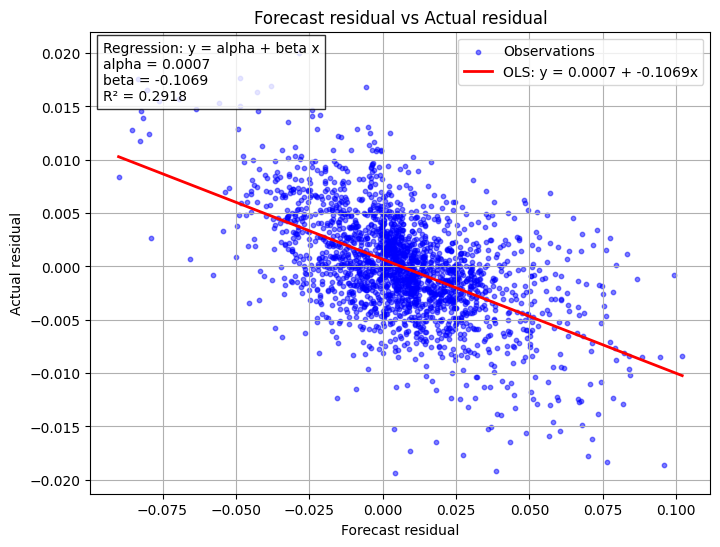

In [146]:
def residuals_plot(
    aux_series,
    aux_series_pred,
):

    #####################################
    # Residuals
    #####################################

    forecast_residual = aux_series_pred - aux_series.shift(1)
    actual_residual = aux_series - aux_series.shift(1)

    x = forecast_residual
    y = actual_residual

    #####################################
    # Nettoyage pour résidus
    #####################################

    reg_df = pd.concat([x, y], axis=1, join="inner")
    reg_df.columns = ["x", "y"]

    reg_df = reg_df.apply(pd.to_numeric, errors="coerce")
    reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

    x_clean = reg_df["x"].astype(float)
    y_clean = reg_df["y"].astype(float)

    #####################################
    # classical regression: y = alpha + beta x
    #####################################

    X_reg = sm.add_constant(x_clean)
    Y_reg = y_clean

    model = sm.OLS(Y_reg, X_reg).fit()

    alpha = model.params["const"]
    beta = model.params["x"]
    r2 = model.rsquared

    print(model.summary())

    # regression line
    x_grid = np.linspace(x_clean.min(), x_clean.max(), 100)
    y_hat = alpha + beta * x_grid

    #####################################
    # Residuals plots + OLS line
    #####################################

    plt.figure(figsize=(8, 6))

    plt.scatter(
        x_clean,
        y_clean,
        s=10,
        alpha=0.5,
        label="Observations",
        color='blue'
    )

    plt.plot(
        x_grid,
        y_hat,
        lw=2,
        label=f"OLS: y = {alpha:.4f} + {beta:.4f}x",
        color='red'
    )

    plt.grid()

    plt.xlabel("Forecast residual")
    plt.ylabel("Actual residual")
    plt.title("Forecast residual vs Actual residual")

    txt = (
        f"Regression: y = alpha + beta x\n"
        f"alpha = {alpha:.4f}\n"
        f"beta = {beta:.4f}\n"
        f"R² = {r2:.4f}"
    )

    plt.text(
        0.02,
        0.98,
        txt,
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8)
    )

    plt.legend()
    plt.show()
    

    return model

residuals_plot(aux_series_is_df.BTC,pred_aux_series_is_df.BTC)

### Note — Signal in the residual tails

The scatter shows a  **negative linear relationship between predicted and realized
residuals**, with an explained variance of **R² ≈ 0.30** — a level that is
meaningful in a quantitative finance context.

The relationship is **concentrated in the tails**: the bulk of the distribution carries
little information, while the extreme deciles drive most of the fit. This suggests a
 cross-sectional implementation:

| Bucket | Predicted residual | Position |
|---|---|---|
| Top 30 % | Most positive | **Short** |
| Middle 40 % | Near zero | Flat |
| Bottom 30 % | Most negative | **Long** |



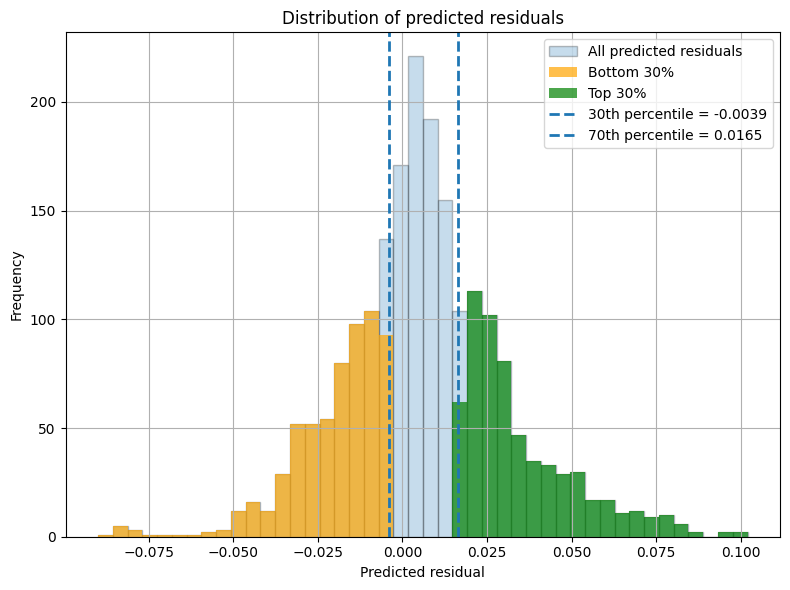

In [147]:
def residuals_hist(
    aux_series,
    aux_series_pred,
):

    #####################################
    # Residuals
    #####################################

    forecast_residual = aux_series_pred - aux_series.shift(1)
    actual_residual = aux_series - aux_series.shift(1)

    x = forecast_residual
    y = actual_residual

    #####################################
    # Nettoyage pour résidus
    #####################################

    reg_df = pd.concat([x, y], axis=1, join="inner")
    reg_df.columns = ["x", "y"]

    reg_df = reg_df.apply(pd.to_numeric, errors="coerce")
    reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

    x_clean = reg_df["x"].astype(float)
    y_clean = reg_df["y"].astype(float)

    
    #####################################
    # Histogramme des résidus prédits
    #####################################

    # Seuils des 30 % extrêmes
    bottom_percentile = x_clean.quantile(0.3)
    top_percentile = x_clean.quantile(0.7)

    # Bottom 30 % : valeurs les plus faibles
    bottom = x_clean[x_clean <= bottom_percentile]

    # Top 30 % : valeurs les plus élevées
    top = x_clean[x_clean >= top_percentile]

    # Bins communs aux trois histogrammes
    bins = np.histogram_bin_edges(
        x_clean,
        bins="auto"
    )

    plt.figure(figsize=(8, 6))
    plt.grid()

    # Distribution complète
    plt.hist(
        x_clean,
        bins=bins,
        alpha=0.25,
        edgecolor="black",
        label="All predicted residuals"
    )

    # Bottom 30 %
    plt.hist(
        bottom,
        bins=bins,
        alpha=0.7,
        label="Bottom 30%",
        color='orange'
    )

    # Top 30 %
    plt.hist(
        top,
        bins=bins,
        alpha=0.7,
        label="Top 30%",
        color='green'
    )

    # Seuils des percentiles
    plt.axvline(
        bottom_percentile,
        linestyle="--",
        linewidth=2,
        label=f"30th percentile = {bottom_percentile:.4f}"
    )

    plt.axvline(
        top_percentile,
        linestyle="--",
        linewidth=2,
        label=f"70th percentile = {top_percentile:.4f}"
    )

    plt.xlabel("Predicted residual")
    plt.ylabel("Frequency")
    plt.title("Distribution of predicted residuals")

    
    plt.legend()
    plt.tight_layout()
    plt.show()

residuals_hist(aux_series_is_df.BTC,pred_aux_series_is_df.BTC)

# How do we compute the pnl of the strategy
PnL is computed on a daily basis, **position by position**.
When a position is opened, the current price is used as the strike:

$$K = S_{t_0}$$

The number of units is derived from the available notional:

$$N = \frac{\text{Notional}}{K}$$

PnL at each date $t$:

$$
PnL_t =
\begin{cases}
(S_t-K)\,N, & \text{Long} \\
(K-S_t)\,N, & \text{Short}
\end{cases}
$$

When the position is closed, the realized PnL is added back to the notional:

$$\text{Notional}_{t+1} = \text{Notional}_t + PnL_{\text{close}}$$

The updated notional is then used to size the next position.



In [148]:
def synthetic_asset_payoff(Notional,price,signal):   

    turnover = (signal.abs()-signal.abs().shift())                        # (turnover[i] ==1) ==> start of the signal, (turnover[i] ==-1) ==> end of the signal
    start_signal = turnover[turnover>0].index 
    end_signal = turnover[turnover<0].index 
    
    if len(start_signal) > len(end_signal):
        end_signal = end_signal.append(
            pd.Index([signal.dropna().index[-1]])
        ) 

    synthetic_asset_pnl = pd.Series(0,index=returns.index, dtype=float)
    
    n_positions = len(start_signal)

    for i in range(n_positions):
        
        opening_date = start_signal[i]

        closing_date = end_signal[i]

        period = pd.date_range(start=opening_date,end=closing_date,freq="D")

        Strike = price.loc[opening_date] 

        pos_type =signal.loc[opening_date] 

        units= Notional/ Strike
        

        for date in period:
            

            if pos_type==1:
                
                synthetic_asset_pnl.loc[date] = (price.loc[date] - Strike)*units
                    
            if pos_type==-1:
                synthetic_asset_pnl.loc[date] = (Strike - price.loc[date])*units 


        Notional = synthetic_asset_pnl.loc[closing_date]+Notional

        
            
    return synthetic_asset_pnl

The strategy is now run across the **entire portfolio**, with an **equal allocation of
$1 to every coin**. Each asset is traded independently under its own signal, and the
aggregate PnL is simply the sum of the individual sleeves.

This equal-weight scheme keeps the comparison clean: no coin dominates the result
through size, so the performance reflects the signal itself rather than the allocation. 

In [149]:
def signal_generation_in_sample(
    aux_series: pd.Series,
    aux_series_pred,
    top_percentile=0.7,
    bottom_percentile=0.3,
):
    forecast_residual = aux_series_pred - aux_series.shift(1)

    bottom_threshold = forecast_residual.quantile(bottom_percentile)
    top_threshold = forecast_residual.quantile(top_percentile)

    signal = pd.Series(0.0, index=forecast_residual.index)

    signal.loc[forecast_residual <= bottom_threshold] = 1.0
    signal.loc[forecast_residual >= top_threshold] = -1.0

    return signal


signals_is_df = pd.DataFrame(index=returns_is.index)
strategy_pnl_is_df = pd.DataFrame(index=returns_is.index)

for coin in returns.columns:
    signal = signal_generation_in_sample(
        aux_series_is_df[coin],
        pred_aux_series_is_df[coin],
        top_percentile=0.7,
        bottom_percentile=0.3,
    )
    signals_is_df[coin] = signal


# PnL is calculated from the unchanged position-calendar and daily-PnL functions.
initial_notional_per_asset = 1.0

for coin in returns.columns:
    
    synthetic_cashflows = synthetic_asset_payoff(
        initial_notional_per_asset,
        price=price[coin].rolling(10).mean(), # the traded asset is the price moving average
        signal=signals_is_df[coin],
    )

    strategy_pnl_is_df[coin] = synthetic_cashflows.reindex(
        strategy_pnl_is_df.index
    ).fillna(0.0)


Below we present the performance of the strategy: the cumulative PnL of the
portfolio, together with the usual summary statistics — initial capital, final capital, annualized return and Sharpe ratio.

In [150]:

def compute_sharpe_ratio(daily_pnl: pd.Series, periods_per_year=365):
    daily_pnl = pd.to_numeric(daily_pnl, errors="coerce").dropna()

    pnl_std = daily_pnl.std()

    if daily_pnl.empty or pnl_std == 0 or pd.isna(pnl_std):
        return np.nan

    return daily_pnl.mean() / pnl_std * np.sqrt(periods_per_year)



def summarize_strategy(
    daily_pnl: pd.Series,
    initial_capital=1.0,
    periods_per_year=365,
):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df = pd.DataFrame()

    # ---------------------------------------------------------
    # Capital & returns
    # ---------------------------------------------------------

    total_pnl = daily_pnl.sum()

    ending_capital = initial_capital + total_pnl

    total_return = (ending_capital - initial_capital) 

    n_years = len(daily_pnl) / periods_per_year

    cagr = (
        (ending_capital / initial_capital) ** (1 / n_years) - 1
        if ending_capital > 0 and n_years > 0
        else np.nan
    )
    

    stats_df["Initial Capital"] = [initial_capital]
    stats_df["Ending Capital"] = [ending_capital]

    stats_df["Total PnL"] = [total_return]
    stats_df["CAGR"] = [cagr]
    stats_df["Sharpe ratio"] = compute_sharpe_ratio(daily_pnl,256)

    
    return stats_df

portfolio_daily_pnl = strategy_pnl_is_df.sum(axis=1).fillna(0.0)


stats_df = summarize_strategy(
    portfolio_daily_pnl,
    initial_capital=len(signals_is_df.columns), # the initial capital is 1$ times the number of coins
)

print("\n===== In-sample PnL Performance Summary =====\n")
print(stats_df.to_string(index=False))



===== In-sample PnL Performance Summary =====

 Initial Capital  Ending Capital    Total PnL     CAGR  Sharpe ratio
              30    12393.173411 12363.173411 1.882249       5.45076


We visualize the strategy's cumulative pnl performance for **BTC** with an initial allocation of 1 dollar.

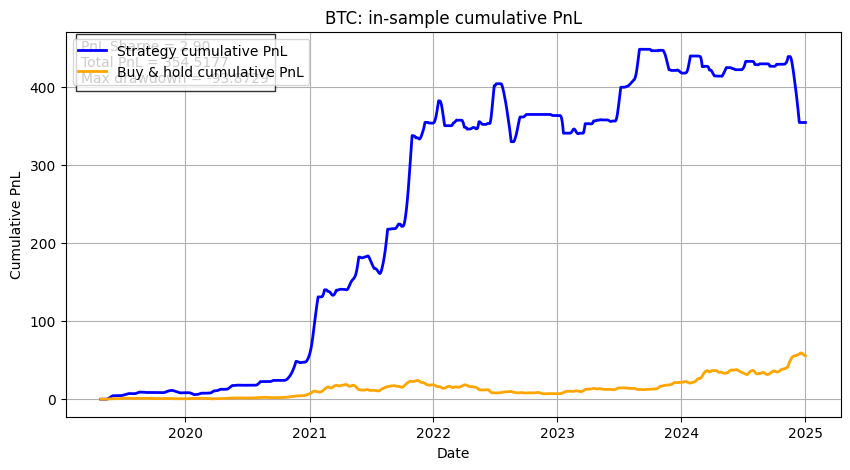

In [151]:

def graphics_plot(
    coin,
    strategy_pnl_df,
    benchmark_returns_df,
    initial_capital=1,
    periods_per_year=365,
):
    strategy_daily_pnl = strategy_pnl_is_df[coin].fillna(0.0)
    strategy_cumulative_pnl = strategy_daily_pnl.cumsum()

    pnl_std = strategy_daily_pnl.std()
    pnl_sharpe = (
        np.nan
        if pnl_std == 0 or pd.isna(pnl_std)
        else strategy_daily_pnl.mean() / pnl_std * np.sqrt(periods_per_year)
    )

    benchmark_returns = benchmark_returns_df[coin].reindex(
        strategy_daily_pnl.index
    ).fillna(0.0)

    benchmark_equity = initial_capital * (1.0 + benchmark_returns).cumprod()
    benchmark_cumulative_pnl = benchmark_equity - initial_capital

    strategy_drawdown = (
        strategy_cumulative_pnl
        - strategy_cumulative_pnl.cummax().clip(lower=0.0)
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        strategy_cumulative_pnl.index,
        strategy_cumulative_pnl.values,
        lw=2,
        color="blue",
        label="Strategy cumulative PnL",
    )

    plt.plot(
        benchmark_cumulative_pnl.index,
        benchmark_cumulative_pnl.values,
        lw=2,
        color="orange",
        label="Buy & hold cumulative PnL",
    )

    plt.title(f"{coin}: in-sample cumulative PnL")
    plt.ylabel("Cumulative PnL")
    plt.xlabel("Date")

    txt = (
        f"PnL Sharpe = {pnl_sharpe:.2f}\n"
        f"Total PnL = {strategy_daily_pnl.sum():.4f}\n"
        f"Max drawdown = {strategy_drawdown.min():.4f}"
    )

    plt.text(
        0.02,
        0.98,
        txt,
        transform=plt.gca().transAxes,
        va="top",
        bbox=dict(facecolor="white", alpha=0.8),
    )

    plt.legend()
    plt.grid()
    plt.show()


graphics_plot(
    "BTC",
    strategy_pnl_is_df,
    returns_is,
)



#### Those results encourage us to do out-of-sample testing of the strategy to access how the strategy could really perform
---

##  Out Of Sample Analysis 
The oos analysis is done on a walkforward basis with an expanding window for the in-sample datas. This approach helps us to constantly update the top and bottm percentile regarding new observations while helping us to prevent overfitting and to simulate real trading behaviour. However we maintain the parameters of the prediction_model function constants: The model itself serves as a rolling estimator of the residuals

The next table give one a visual idea of the approach

### Expanding Window Timeline

| Run | In-Sample (Train) Window | Out-of-Sample (Test) Window |
| :--- | :--- | :--- |
| **Run 1** | Month 1 to Month 12 *(1 Year)* | Month 13 to Month 15 *(3 Months)* |
| **Run 2** | Month 1 to Month 15 *(1 Year + 3 Months)* | Month 16 to Month 18 *(3 Months)* |
| **Run 3** | Month 1 to Month 18 *(1 Year + 6 Months)* | Month 19 to Month 21 *(3 Months)* |
| **Run 4** | Month 1 to Month 21 *(1 Year + 9 Months)* | Month 22 to Month 24 *(3 Months)* |


***For each run, we use the In-Sample period to define the top and bottom percentile and use them as threshold for the Out-of-Sample period***



In [152]:
pred_aux_series_df = pd.DataFrame(index= aux_series_df.index )

for coin in returns.columns:
    aux_series_pred = prediction_model(aux_series_is_df,coin, normalization_window=10, optimisation_window=10, env_window=0)

    pred_aux_series_df[coin]=aux_series_pred

In [153]:
def signal_generation_oos(aux_series: pd.Series, aux_series_pred, top_threshold, bottom_threshold):
    
    forecast_residual =  aux_series_pred - aux_series.shift(1)


    bottom_threshold = bottom_threshold

    top_threshold = top_threshold

    signal = pd.Series(
        0.0,
        index=forecast_residual.index
    )

    signal.loc[
        forecast_residual <= bottom_threshold
    ] = 1.0

    signal.loc[
        forecast_residual >= top_threshold
    ] = -1.0


    return signal



In [154]:
idx = pd.to_datetime(aux_series_df.index)

# --- WALK-FORWARD CONFIGURATION ---

start_date = idx[0]
train_end = start_date + pd.DateOffset(months=12)

# Expansion step (out-of-sample): 3 months
step_size = pd.DateOffset(months=3)

signals_oos_df = pd.DataFrame(
    0.0,
    index=idx[idx >= train_end],
    columns=aux_series_df.columns,
    dtype=float,
)

run = 1

while train_end < idx[-1]:
    test_end = train_end + step_size

    train_idx = idx[
        (idx >= start_date)
        & (idx < train_end)
    ]

    # Predicted and actual auxiliary series for the expanding training sample
    pred_aux_series_is_df = pred_aux_series_df.loc[train_idx]
    aux_series_is_df = aux_series_df.loc[train_idx]

    # Thresholds are estimated only from the training sample
    forecast_residual_is_df = (
        pred_aux_series_is_df
        - aux_series_is_df.shift()
    )

    bottom_threshold = forecast_residual_is_df.quantile(0.3)
    top_threshold = forecast_residual_is_df.quantile(0.7)

    # Out-of-sample period for this run
    test_idx = idx[
        (idx >= train_end)
        & (idx < test_end)
    ]

    optimisation_window = 10

    pred_test_idx = idx[
        (
            idx
            >= train_end
            - pd.DateOffset(days=optimisation_window)
        )
        & (idx < test_end)
    ]

    aux_series_oos_df = aux_series_df.loc[pred_test_idx]

    for coin in returns.columns:
        aux_series_pred = prediction_model(
            aux_series_oos_df,
            coin,
            normalization_window=10,
            optimisation_window=10,
            env_window=0,
        )

        signal = signal_generation_oos(
            aux_series_oos_df[coin].loc[test_idx],
            aux_series_pred,
            top_threshold[coin],
            bottom_threshold[coin],
        )

        signals_oos_df.loc[signal.index, coin] = signal

    train_end += step_size
    run += 1


# --------------------------------------------------------------------------
# PnL calculation
# The calendar and daily-PnL functions are used unchanged.
# Signals are first placed on the complete return index so that an opening
# position on the first OOS date is correctly detected by the calendar.
# --------------------------------------------------------------------------

signals_oos_full_df = pd.DataFrame(
    0.0,
    index=returns.index,
    columns=returns.columns,
)

common_signal_index = signals_oos_full_df.index.intersection(
    signals_oos_df.index
)

signals_oos_full_df.loc[
    common_signal_index,
    signals_oos_df.columns,
] = signals_oos_df.loc[common_signal_index]

strategy_pnl_oos_df = pd.DataFrame(
    0.0,
    index=signals_oos_df.index,
    columns=returns.columns,
)

initial_notional_per_asset = 1.0

for coin in returns.columns:
    

    coin_daily_pnl = synthetic_asset_payoff(
        initial_notional_per_asset,
        price=price[coin].rolling(10).mean(),
        signal=signals_oos_full_df[coin],
    )

    strategy_pnl_oos_df[coin] = coin_daily_pnl.reindex(
        strategy_pnl_oos_df.index
    ).fillna(0.0)


We can now present the performance of the strategy on oos datas: the cumulative PnL of the
portfolio, together with other statistics — initial capital, final capital, annualized return and Sharpe ratio, profit factor, hit ratio, max drawdowns, beta against BTC, alpha, etc.

In [155]:
def returns_to_daily_pnl(
    returns_series: pd.Series,
    initial_capital=1,
):
    
    returns_series = pd.to_numeric(
        returns_series,
        errors="coerce",
    ).fillna(0.0)

    equity = initial_capital * (1.0 + returns_series).cumprod()
    daily_pnl = equity.diff()

    if len(daily_pnl) > 0:
        daily_pnl.iloc[0] = equity.iloc[0] - initial_capital

    return daily_pnl

def drawdown_series(daily_pnl: pd.Series):
    """Drawdown expressed directly in PnL units, not in return percentages."""
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    cumulative_pnl = daily_pnl.cumsum()
    running_peak = cumulative_pnl.cummax().clip(lower=0.0)

    return (cumulative_pnl - running_peak)/running_peak



def summarize_strategy_oos(
    daily_pnl: pd.Series,
    benchmark_daily_pnl: pd.Series | None = None,
    initial_capital=1.0,
    periods_per_year=365,
):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df = pd.DataFrame()

    # ---------------------------------------------------------
    # Capital & returns
    # ---------------------------------------------------------

    total_pnl = daily_pnl.sum()

    ending_capital = initial_capital + total_pnl

    total_return = (ending_capital - initial_capital) 

    n_years = len(daily_pnl) / periods_per_year

    cagr = (
        (ending_capital / initial_capital) ** (1 / n_years) - 1
        if ending_capital > 0 and n_years > 0
        else np.nan
    )

    average_daily_pnl = daily_pnl.mean()


    stats_df["Initial Capital"] = [initial_capital]
    stats_df["Ending Capital"] = [ending_capital]

    stats_df["Total PnL"] = [total_return]
    stats_df["CAGR"] = [cagr]

    stats_df["Average Daily PnL"] = [average_daily_pnl]

    stats_df["PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            daily_pnl,
            periods_per_year,
        )
    ]

    # ---------------------------------------------------------
    # Profit factor / hit ratio
    # ---------------------------------------------------------

    profit = daily_pnl[daily_pnl > 0].sum()
    loss = -daily_pnl[daily_pnl < 0].sum()

    profit_factor = profit / loss if loss != 0 else np.inf

    stats_df["Profit Factor"] = [profit_factor]

    hit_ratio = (daily_pnl > 0).mean()

    stats_df["Hit Ratio"] = [hit_ratio]

    # ---------------------------------------------------------
    # Drawdown
    # ---------------------------------------------------------

    drawdown = drawdown_series(daily_pnl)

    duration = (
        (drawdown < 0)
        .groupby((drawdown == 0).cumsum())
        .cumcount()
    )

    stats_df["Max Drawdown"] = [drawdown.min()]

    stats_df["Average Drawdown"] = [
        drawdown[drawdown < 0].mean()
    ]

    stats_df["Max Drawdown Duration"] = [
        duration.max()
    ]

    # ---------------------------------------------------------
    # Benchmark
    # ---------------------------------------------------------

    if benchmark_daily_pnl is not None:

        aligned = pd.concat(
            [
                daily_pnl.rename("strategy_pnl"),
                benchmark_daily_pnl.rename("benchmark_pnl"),
            ],
            axis=1,
            join="inner",
        ).dropna()

        if not aligned.empty:

            benchmark_var = aligned["benchmark_pnl"].var()

            beta = (
                aligned["strategy_pnl"].cov(
                    aligned["benchmark_pnl"]
                )
                / benchmark_var
            )

            daily_alpha_pnl = (
                aligned["strategy_pnl"].mean()
                - beta
                * aligned["benchmark_pnl"].mean()
            )

            stats_df["Benchmark PnL Correlation"] = [
                aligned["strategy_pnl"].corr(
                    aligned["benchmark_pnl"]
                )
            ]

            stats_df["Beta"] = [beta]


            stats_df["Annualized Alpha PnL"] = [
                daily_alpha_pnl * periods_per_year
            ]

    return stats_df

In [156]:
portfolio_daily_pnl = strategy_pnl_oos_df.sum(axis=1).fillna(0.0)

market_returns_oos = raw_returns['BTC'].reindex(portfolio_daily_pnl.index)

#market_returns_oos = raw_returns.reindex(
#    portfolio_daily_pnl.index
#).mean(axis=1)

benchmark_daily_pnl = returns_to_daily_pnl(
    market_returns_oos,
    initial_capital=1.0,
)

stats_df = summarize_strategy_oos(
    portfolio_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=len(strategy_pnl_oos_df.columns),
)

print("\n===== Out-of-sample PnL Performance Summary =====\n")
print(stats_df.to_string(index=True))



===== Out-of-sample PnL Performance Summary =====

   Initial Capital  Ending Capital    Total PnL      CAGR  Average Daily PnL  PnL Sharpe Ratio  Profit Factor  Hit Ratio  Max Drawdown  Average Drawdown  Max Drawdown Duration  Benchmark PnL Correlation      Beta  Annualized Alpha PnL
0               30     6814.284064  6784.284064  2.181697           3.965099           6.05848       3.664288   0.790181     -0.592475         -0.060586                    105                  -0.040041 -2.828561           1454.076919


## Synthetic Asset Construction

> ***The principal purpose of this construction is to assess the potential feasability of the    approach.***

We construct a **synthetic tradable exposure** using price moving average options. The replication is based on a classic **option-based synthetic forward structure**.

### Position Replication

* **Long Synthetic Exposure**  
  A long position is obtained by buying an at-the-money (ATM) call and selling an ATM  put:
  
   $$V^{\text{long}} = C_{\text{atm}} - P_{\text{atm}}$$

* **Short Synthetic Exposure**  
  A short position is obtained by selling an ATM call and buying an ATM put:
  
    $$V^{\text{short}} = P_{\text{atm}} - C_{\text{atm}}$$

### Pricing Framework

The option premiums are estimated using the **Black-Scholes pricing framework**. This allows the trading signal to be converted into a realistic synthetic exposure. 

#### A Robust First Estimator
Although the classic Black-Scholes model is designed for European vanilla options, it serves as an **excellent first estimator** in this strategy. Because the strike is set to the asset price at the calculation date ($K = S_t$), the formula provides a clean, instantaneous proxy to standardize premium estimation the computational heavy-lifting of exotic closed-form approximations or Monte Carlo simulations.

#### Frictions and Realism
Due to the exotic and over-the-counter (OTC) nature of moving average options, we cannot confincently define **Commissions** due to the lack pf public centralized benchmarks.

In oder to maintain backtest realism and compensate for the absence of commissions, we apply a range of **Slippage penalties** applied to simulate the bid-ask spreads.

## Synthetic exposure with slippages

Option premiums are computed using a Black-Scholes framework with the following inputs:
* $S_t$: Current underlying level
* $K$: ATM strike price
* $r_t$: Risk-free rate (aligned with the return index and forward-filled)
* $\sigma_t$ Annualized rolling volatility (estimated from historical returns using a 365-day convention)
* $T$: Time to maturity.
* $C$: The call option
* $S$: The put options

---

### 1. Position Opening

The opening for a long synthetic exposure ( incorporating execution slippage ($s$) ) is given by:

$$V^{\text{long}}= C_{\text{ask}} - P_{\text{bid}}$$

Where bid and ask prices are derived from mid-prices:

$$C_{\text{ask}} = C_{\text{mid}}(1 + s)$$
$$P_{\text{bid}} = P_{\text{mid}}(1 - s)$$

Thus, the total net opening cost is expressed as:

$$
\begin{aligned}
V^{\text{long}}
&= C_{\text{ask}} - P_{\text{bid}} \\[4pt]
&= C_{\text{mid}}(1+s) - P_{\text{mid}}(1-s) \\[4pt]
&= \underbrace{\left(C_{\text{mid}}-P_{\text{mid}}\right)}_{\text{mid-price synthetic}}
 \;+\; \underbrace{\left(C_{\text{mid}}+P_{\text{mid}}\right)s}_{\text{transaction cost}}
\end{aligned}
$$
similar to that;
$$
\begin{aligned}
V^{\text{Short}}
&= P_{\text{ask}} - C_{\text{bid}} \\[4pt]
&= P_{\text{mid}}(1+s) - C_{\text{mid}}(1-s) \\[4pt]
&= \underbrace{\left(P_{\text{mid}}-C_{\text{mid}}\right)}_{\text{mid-price synthetic}}
 \;+\; \underbrace{\left(C_{\text{mid}}+P_{\text{mid}}\right)s}_{\text{transaction cost}}
\end{aligned}
$$
---



### 2. Early Closing (Prior to Maturity)

If a position is liquidated before expiration, the synthetic contract is unwound in the market. The options must be re-priced using the exact remaining time to maturity ($T_{\text{remaining}}$):

$$T_{\text{remaining}} = \frac{\text{Maturity Date} - \text{Closing Date}}{365}$$

For example, when exiting a long synthetic exposure, the position is closed by selling the ATM call at the **bid** price and buy ATM put at the **ask** price with a maturity of $T_{\text{remaining}}$:

---

### 3. Settlement at Maturity

If the position is held until expiration and the signal is non-zero, no closing position is performed. Instead we renew position according to the signal in order to maintain our exposure

 


In [157]:
# ==========================================================================
# Identify the days for opening,renew or close the position
# ==========================================================================
def build_position_dates( signal, maturity_days=10, day_count=252):
    turnover = (signal.abs()-signal.abs().shift())                        # (turnover[i] ==1) ==> start of the signal, (turnover[i] ==-1) ==> end of the signal
    start_signal = turnover[turnover>0].index 
    end_signal = turnover[turnover<0].index 
    
    if len(start_signal) > len(end_signal): 
        end_signal = end_signal.append(                                  # cloturing the position at the last date if the position is still open
            pd.Index([signal.dropna().index[-1]])     
        )
    
    periods_df = pd.DataFrame({
        "start_date":start_signal,
        "end_date":end_signal
    })

    position_calendar = pd.DataFrame()
    open_dates = []      # dates for opening position  
    close_dates = []     # dates for closing
    
    renewals = []        # True if the closing date is a date for renewing the position

    remaining_days = []  #remaining days for the forward expirity 
    remaining_times = [] #remaining days / 252

    for start, end in zip(periods_df["start_date"], periods_df["end_date"]):

        maturity_date = start + pd.Timedelta(days=maturity_days)

        if (end-start).days <= 10:          # the signal period > maturity   
            open_dates.append(start)
            close_dates.append(end)
            renewals.append(False)

            rem_days = (maturity_date - end).days
            remaining_days.append(rem_days)
            remaining_times.append(round(rem_days / day_count,4))

            continue
        
        else:                           # the signal period < maturity, so we have to take consideration of the renewal dates
            open = start
            close = end 
            while open + pd.Timedelta(days=10) < end:   # the loop helps to consider all the position renewals
                renewal_date = open + pd.Timedelta(days=10)
                
                open_dates.append(open)

                close = renewal_date

                close_dates.append(close)
                
                renewals.append(True)


                rem_days = 0       # since the contract hit the maturity date
                remaining_days.append(rem_days)
                remaining_times.append(round(rem_days / day_count,4))

                open= renewal_date
            
            #the last period, which is < maturity 
            open_dates.append(open)       
            close_dates.append(end)
            rem_days = (open + pd.Timedelta(days=maturity_days) - end).days
            renewals.append(False)
            remaining_days.append(rem_days)
            remaining_times.append(round(rem_days / day_count,4))

            

        
    
    position_calendar["open_date"] = open_dates
    position_calendar["close_date"] = close_dates

    
    position_calendar["renewal ?"] = renewals

    position_calendar["remaining_days"] = remaining_days
    position_calendar["remaining_time"] = remaining_times

    return position_calendar

In [158]:
# ==========================================================================
# - Black Scholes function and importing risk-free rates 
# ==========================================================================
from scipy.stats import norm
from pandas_datareader import data as web
def blackScholes(r, S, K, T, sigma, option_type="c"):
    "Calculate BS price of call/put"
    # r : risk free rate
    # S : current price
    # K : strike price
    # sigma : volatility
    # option_type : 'c' for call, 'p' for put

    option_type = option_type.lower()

    if option_type not in ["c", "p"]:
        raise ValueError("option_type must be 'c' for Call or 'p' for Put")

    if sigma <= 0 or T <= 0:
        return 0

    d1 = (np.log(S/K) + (r + sigma**2/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type == "c":
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)

    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)

    return price


start = "2019-01-01"
end = "2026-06-23"

# 3 months treasury rates US
rf = web.DataReader("DGS3MO", "fred", start, end)

rf = rf.rename(columns={"DGS3MO": "rf_annual"})
rf = rf.dropna()

# treasury rates in decimal
rf["rf_annual"] = rf["rf_annual"] / 100



In [159]:
# ==========================================================================
# - Synthetic forward premimum at each opening,renew or closing date
# ==========================================================================


def synthetic_asset_costs(position_calendar_df,returns,rf,signal,mat_period, vol_window,slippage):

    rf_daily = rf.reindex(returns.index).ffill()
   
    volatility = returns.rolling(window=vol_window, min_periods=1).std() * np.sqrt(256)

    synthetic_asset_premium = pd.Series(0,index=returns.index, dtype=float)
    
    opening_dates = position_calendar_df['open_date'].reset_index(drop=True).drop_duplicates()
    
    T = (mat_period)/256
    
    for date in opening_dates:
       
        call_premium = blackScholes(rf_daily[date],1,1,T,volatility.loc[date],option_type="c")
        
        put_premium = blackScholes(rf_daily[date],1,1,T,volatility.loc[date],option_type="p")
        

        if signal.loc[date] == 1:               #long position
            cost = put_premium*(1-slippage) - call_premium*(1+slippage)

        if signal.loc[date]==-1:                #short position
            cost = call_premium*((1-slippage))-put_premium*(1+slippage)

        synthetic_asset_premium[date] = cost


    closing_dates = position_calendar_df['close_date'][position_calendar_df['renewal ?']==False]
    remaining_time = ( position_calendar_df[position_calendar_df['renewal ?'] == False].set_index("close_date")["remaining_time"])

    
    for date in closing_dates:
       
        call_premium = blackScholes(rf_daily[date],1,1,remaining_time.loc[date],volatility.loc[date],option_type="c")
        call_premium = call_premium
        put_premium = blackScholes(rf_daily[date],1,1,remaining_time.loc[date],volatility.loc[date],option_type="p")
        put_premium=put_premium

        if signal.loc[date] == 1:               #short position for cloturing the long position
            cost = call_premium*(1-slippage)-put_premium*(1+slippage)

        if signal.loc[date]==-1:                #long position for cloturing the short position
            cost = put_premium*(1-slippage)-call_premium*(1+slippage)

        synthetic_asset_premium[date] = cost




    return synthetic_asset_premium

    


In [164]:
# ==========================================================================
# - Synthetic forward premimum at each opening,renew or closing date
# ==========================================================================

def Call_payoff(actual_price, Strike,premium):
    return np.max([0,(-Strike+actual_price)])
def Put_payoff(actual_price, Strike,premium):
    return np.max([0,(Strike-actual_price)])


def synthetic_asset_payoff_with_slip(position_calendar_df,price,rf,signal,mat_period, vol_window,slippage):    

    synthetic_asset_pnl = pd.Series(0,index=returns.index, dtype=float)
    rf_daily = rf.reindex(price.index).ffill() 
    volatility = np.log(price).diff().rolling(window=vol_window, min_periods=1).std() * np.sqrt(256)
    
    n_positions = len(position_calendar_df)

    T = (mat_period)/256


    Notional = 1

    for i in range(n_positions):

        
        opening_date = position_calendar_df.iloc[i]['open_date']

        closing_date = position_calendar_df.iloc[i]['close_date']

        period = pd.date_range(start=opening_date,end=closing_date,freq="D")

        Strike = price.loc[opening_date] 

        pos_type =signal.loc[opening_date] 

        units= Notional/ Strike

        #opening the position
        call_premium = blackScholes(rf_daily[opening_date],Strike,Strike,T,volatility.loc[opening_date],option_type="c")
        put_premium = blackScholes(rf_daily[opening_date],Strike,Strike,T,volatility.loc[opening_date],option_type="p")
        transactions_cost = (call_premium+put_premium)*slippage*units
        

        for date in period:
            call_pnl = Call_payoff(price.loc[date],Strike,call_premium)*units
            put_pnl = Put_payoff(price.loc[date],Strike,put_premium)*units
            

            if pos_type==1:
                
                synthetic_asset_pnl.loc[date] = call_pnl - put_pnl - transactions_cost
                    
            if pos_type==-1:
                synthetic_asset_pnl.loc[date] = - call_pnl + put_pnl -transactions_cost

            
        # closing the position 
        if position_calendar_df.iloc[i]['renewal ?'] == False:
            remaining_time = position_calendar_df.iloc[i]['remaining_days']/256
            Strike = price.loc[closing_date]
            call_premium = blackScholes(rf_daily[opening_date],Strike,price.loc[closing_date],remaining_time,volatility.loc[date],option_type="c")*units
            put_premium = blackScholes(rf_daily[opening_date],Strike,price.loc[closing_date],remaining_time,volatility.loc[date],option_type="p")*units
            synthetic_asset_pnl.loc[closing_date]+= -(call_premium+put_premium)*slippage



        Notional = synthetic_asset_pnl.loc[closing_date]+Notional

        
            
    return synthetic_asset_pnl


### Sensibility to slippage

The objective is to see how the strategy performs regarding different slippages assumptions

In [165]:
# ==========================================================================
# Step 0 - Gross and net PnL portfolio construction
# ==========================================================================

signals_df = signals_oos_full_df.copy()

strategy_gross_pnl_df = strategy_pnl_oos_df.copy()
strategy_net_pnl_df = pd.DataFrame(
    0.0,
    index=strategy_gross_pnl_df.index,
    columns=strategy_gross_pnl_df.columns,
)

transaction_cost_pnl_df = pd.DataFrame(
    0.0,
    index=strategy_gross_pnl_df.index,
    columns=strategy_gross_pnl_df.columns,
)

slippages = np.concatenate(([0],np.arange(0.05,0.4,0.1)))


pnl_after_slippage_df = pd.DataFrame(index=strategy_gross_pnl_df.index,columns=slippages)


for slippage in slippages:
    for coin in returns.columns:
        position_calendar_df = build_position_dates(
            signals_df[coin]
        )

        pnl_cashflows = synthetic_asset_payoff_with_slip(
            position_calendar_df,
            price[coin].rolling(10).mean(),
            rf["rf_annual"],
            signals_df[coin],
            10,
            30,
            slippage,
        )



        strategy_net_pnl_df[coin] = pnl_cashflows
        
    portfolio_net_daily_pnl = strategy_net_pnl_df.sum(axis=1) 

    pnl_after_slippage_df.loc[:,slippage] = portfolio_net_daily_pnl


# Equal-weighted portfolio PnL
portfolio_gross_daily_pnl = strategy_gross_pnl_df.sum(axis=1)


# Benchmark PnL on the same normalized initial capital
market_returns = raw_returns['BTC'].reindex(
    portfolio_daily_pnl.index
)

benchmark_daily_pnl = returns_to_daily_pnl(
    market_returns,
    initial_capital=1.0,
)


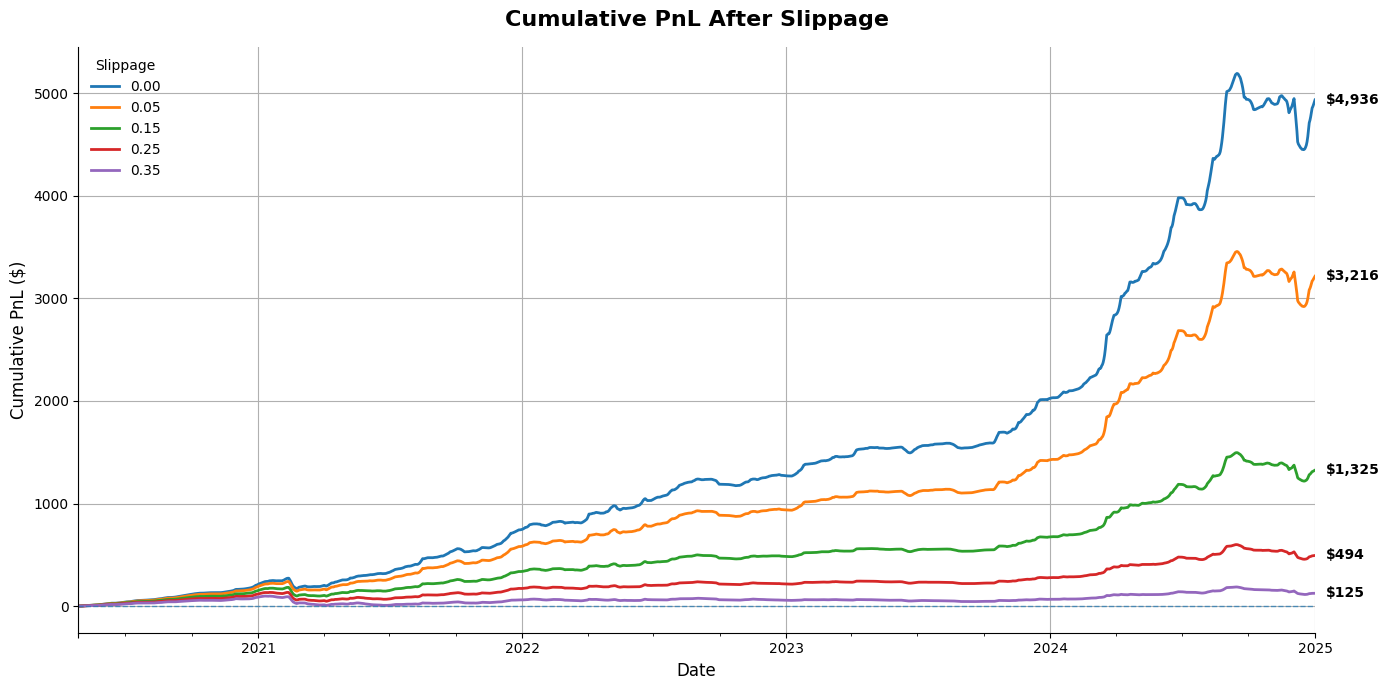

In [166]:

cumulative_pnl = pnl_after_slippage_df.cumsum()

fig, ax = plt.subplots(figsize=(14, 7))

# graphs
cumulative_pnl.plot(
    ax=ax,
    linewidth=2
)


ax.axhline(
    y=0,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

# Titles et labels
ax.set_title(
    "Cumulative PnL After Slippage",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Cumulative PnL ($)", fontsize=12)


ax.grid(
    True
)


labels = [
    f"{col:.2f}"
    for col in cumulative_pnl.columns
]

ax.legend(
    labels=labels,
    title="Slippage",
    frameon=False,
    fontsize=10
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

#plot
for column in cumulative_pnl.columns:
    final_value = cumulative_pnl[column].iloc[-1]

    ax.annotate(
        f"${final_value:,.0f}",
        xy=(cumulative_pnl.index[-1], final_value),
        xytext=(8, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

### Slippage Analysis

By analysing the slippage effect, one can remark that the performance quickly degrades as the slippage rise : The strategy is sensible to the slippage

Unless other imporvements, the strategy could not be easily implemented.


### Perfoamce analysis

Nevertheless, analysing the overall performance performance of the strategy for a small slippage (5 %).

The main measures are total and annualized PnL, the Sharpe Ratio, profit factor, hit ratio, drawdown in PnL units, beta, alpha, and information ratio relative to an equal-weighted buy-and-hold benchmark.

The strategy portfolio is equally weighted across the selected cryptocurrencies. Each asset begins with the same normalized notional.

In [163]:
# ==========================================================================
# Step 1 - PnL analysis against buy and hold
# ==========================================================================

# Convenience alias 
portfolio_daily_pnl = pnl_after_slippage_df.iloc[:,1] # slippage of 5%


strategy_stats_df = summarize_strategy(
    portfolio_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=1.0,
)

buy_hold_stats_df = summarize_strategy(
    benchmark_daily_pnl,
    benchmark_daily_pnl,
    initial_capital=1.0,
)

stats_df = pd.concat(
    [strategy_stats_df, buy_hold_stats_df],
    axis=0,
)

stats_df.index = [
    "Strategy - Net PnL",
    "Buy and Hold PnL",
]

print(f"\n===== PnL Performance Summary with a slippage of {slippages[1]} =====\n")
print(stats_df.to_string(index=True))


gross_cumulative_pnl = portfolio_gross_daily_pnl.cumsum()
net_cumulative_pnl = portfolio_daily_pnl.cumsum()
benchmark_cumulative_pnl = benchmark_daily_pnl.cumsum()

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

# Plot 1: cumulative PnL
axes[0].plot(
    gross_cumulative_pnl,
    label="Strategy gross PnL",
    color="blue",
    alpha=0.45,
)

axes[0].plot(
    net_cumulative_pnl,
    label="Strategy net PnL",
    color="blue",
)

axes[0].plot(
    benchmark_cumulative_pnl,
    label="Buy & hold PnL",
    color="orange",
)

axes[0].set_title("Strategy vs buy & hold cumulative PnL")
axes[0].set_ylabel("Cumulative PnL")
axes[0].legend()
axes[0].grid(True)

# Plot 2: relative cumulative PnL
relative_cumulative_pnl = (
    net_cumulative_pnl
    - benchmark_cumulative_pnl
)

axes[1].plot(
    relative_cumulative_pnl,
    color="black",
)

axes[1].axhline(
    0.0,
    color="grey",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title(
    "Relative cumulative PnL: strategy minus buy & hold"
)
axes[1].set_ylabel("Relative cumulative PnL")
axes[1].set_xlabel("Time")
axes[1].grid(True)

plt.tight_layout()
plt.show()


TypeError: summarize_strategy() got multiple values for argument 'initial_capital'

In [ ]:


def drawdown_analysis(daily_pnl: pd.Series):
    daily_pnl = pd.to_numeric(
        daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    drawdown_df = pd.DataFrame()

    drawdown_pnl = drawdown_series(daily_pnl)

    duration = (
        (drawdown_pnl < 0)
        .groupby((drawdown_pnl == 0).cumsum())
        .cumcount()
    )

    drawdown_df["Max Drawdown (PnL)"] = [
        drawdown_pnl.min()
    ]
    drawdown_df["Max Drawdown Duration"] = [
        duration.max()
    ]
    drawdown_df["Average Drawdown (PnL)"] = [
        drawdown_pnl[drawdown_pnl < 0].mean()
    ]
    drawdown_df["Average Drawdown Duration"] = [
        duration[drawdown_pnl < 0].mean()
    ]

    return drawdown_df



===== PnL Drawdown Analysis =====

 Max Drawdown (PnL)  Max Drawdown Duration  Average Drawdown (PnL)  Average Drawdown Duration
               -inf                   1710                    -inf                      855.5


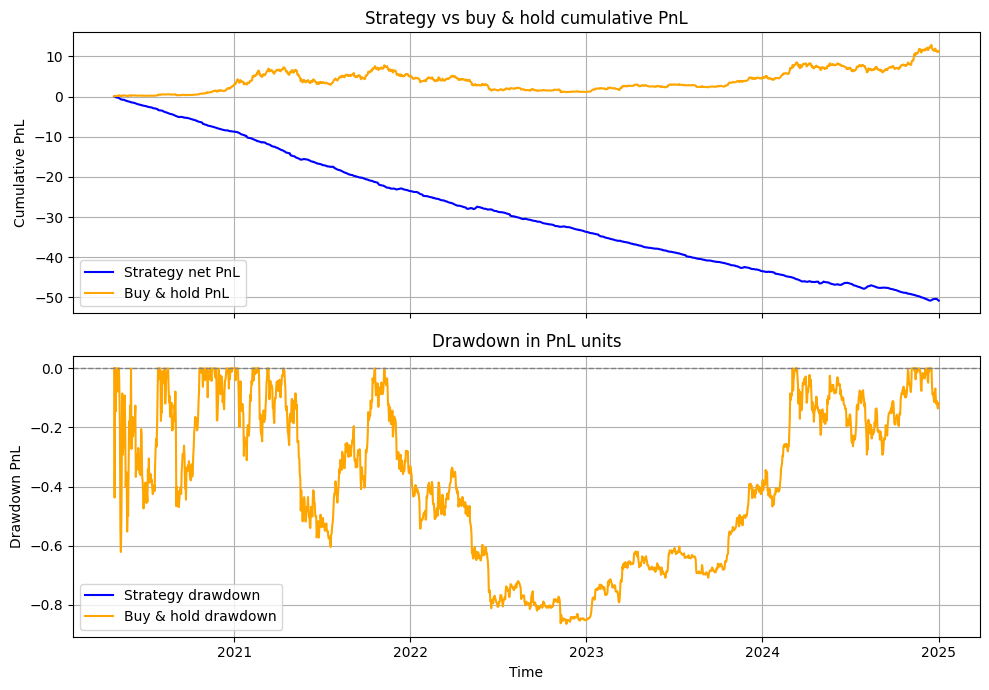

In [ ]:
# ==========================================================================
# Step 2 - PnL drawdown analysis against buy and hold
# ==========================================================================

drawdown_stats = drawdown_analysis(
    portfolio_net_daily_pnl
)

print("\n===== PnL Drawdown Analysis =====\n")
print(drawdown_stats.to_string(index=False))

strategy_cumulative_pnl = portfolio_net_daily_pnl.cumsum()
benchmark_cumulative_pnl = benchmark_daily_pnl.cumsum()

strategy_drawdown_pnl = drawdown_series(
    portfolio_net_daily_pnl
)

benchmark_drawdown_pnl = drawdown_series(
    benchmark_daily_pnl
)

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

# Plot 1: cumulative PnL
axes[0].plot(
    strategy_cumulative_pnl,
    label="Strategy net PnL",
    color="blue",
)

axes[0].plot(
    benchmark_cumulative_pnl,
    label="Buy & hold PnL",
    color="orange",
)

axes[0].set_title("Strategy vs buy & hold cumulative PnL")
axes[0].set_ylabel("Cumulative PnL")
axes[0].legend()
axes[0].grid(True)

# Plot 2: drawdown in PnL units
axes[1].plot(
    strategy_drawdown_pnl,
    label="Strategy drawdown",
    color="blue",
)

axes[1].plot(
    benchmark_drawdown_pnl,
    label="Buy & hold drawdown",
    color="orange",
)

axes[1].axhline(
    0.0,
    color="grey",
    linestyle="--",
    linewidth=1,
)

axes[1].set_title("Drawdown in PnL units")
axes[1].set_ylabel("Drawdown PnL")
axes[1].set_xlabel("Time")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
# ==========================================================================
# Step 3 - Alpha contribution analysis in PnL units
# ==========================================================================

import statsmodels.api as sm

regression_df = pd.concat(
    [
        portfolio_net_daily_pnl.rename("strategy_pnl"),
        benchmark_daily_pnl.rename("benchmark_pnl"),
    ],
    axis=1,
    join="inner",
).fillna(0.0)

X = sm.add_constant(
    regression_df["benchmark_pnl"]
)

Y = regression_df["strategy_pnl"]

model = sm.OLS(Y, X).fit()

beta = model.params["benchmark_pnl"]
daily_alpha_pnl = model.params["const"]
annualized_alpha_pnl = daily_alpha_pnl * 365
alpha_tstat = model.tvalues["const"]

active_pnl = (
    regression_df["strategy_pnl"]
    - beta * regression_df["benchmark_pnl"]
)

active_pnl_std = active_pnl.std()

information_ratio = (
    np.nan
    if active_pnl_std == 0 or pd.isna(active_pnl_std)
    else active_pnl.mean()
    / active_pnl_std
    * np.sqrt(365)
)

print("\n===== Alpha PnL Contribution Analysis =====\n")
print(f"Daily Alpha PnL: {daily_alpha_pnl:.6f}")
print(f"PnL Beta vs buy and hold: {beta:.4f}")
print(f"Annualized Alpha PnL: {annualized_alpha_pnl:.6f}")
print(f"Alpha t-statistic: {alpha_tstat:.2f}")
print(f"PnL Information Ratio: {information_ratio:.2f}")



===== Alpha PnL Contribution Analysis =====

Daily Alpha PnL: -0.029649
PnL Beta vs buy and hold: -0.0071
Annualized Alpha PnL: -10.821752
Alpha t-statistic: -31.13
PnL Information Ratio: -14.39


### General summary of the residual strategy's PnL metrics


In [ ]:
def general_summarize_strategy(
    gross_daily_pnl: pd.Series,
    net_daily_pnl: pd.Series,
    signals_df: pd.DataFrame,
    benchmark_daily_pnl: pd.Series,
    periods_per_year=365,
):
    stats_df = pd.DataFrame()

    gross_daily_pnl = pd.to_numeric(
        gross_daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    net_daily_pnl = pd.to_numeric(
        net_daily_pnl,
        errors="coerce",
    ).fillna(0.0)

    stats_df["Gross Total PnL"] = [
        gross_daily_pnl.sum()
    ]
    stats_df["Net Total PnL"] = [
        net_daily_pnl.sum()
    ]

    stats_df["Gross PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            gross_daily_pnl,
            periods_per_year,
        )
    ]

    stats_df["Net PnL Sharpe Ratio"] = [
        compute_sharpe_ratio(
            net_daily_pnl,
            periods_per_year,
        )
    ]

    turnover = (
        (signals_df - signals_df.shift())
        .abs()
        .sum(axis=1)
        / len(signals_df.columns)
    )

    stats_df["Average Turnover"] = [
        turnover.mean()
    ]

    stats_df["Annualized Net PnL"] = [
        net_daily_pnl.mean() * periods_per_year
    ]

    stats_df["Annualized PnL Volatility"] = [
        net_daily_pnl.std()
        * np.sqrt(periods_per_year)
    ]

    net_drawdown_pnl = drawdown_series(
        net_daily_pnl
    )

    stats_df["Max Drawdown (PnL)"] = [
        net_drawdown_pnl.min()
    ]

    active_net_pnl = net_daily_pnl[
        net_daily_pnl != 0
    ]

    stats_df["Hit Ratio"] = [
        np.nan
        if active_net_pnl.empty
        else (active_net_pnl > 0).mean()
    ]

    regression_df = pd.concat(
        [
            net_daily_pnl.rename("strategy_pnl"),
            benchmark_daily_pnl.rename("benchmark_pnl"),
        ],
        axis=1,
        join="inner",
    ).fillna(0.0)

    stats_df["Benchmark PnL Correlation"] = [
        regression_df["strategy_pnl"].corr(
            regression_df["benchmark_pnl"]
        )
    ]

    X = sm.add_constant(
        regression_df["benchmark_pnl"]
    )

    Y = regression_df["strategy_pnl"]

    model = sm.OLS(Y, X).fit()

    beta = model.params["benchmark_pnl"]
    daily_alpha_pnl = model.params["const"]

    stats_df["PnL Beta"] = [beta]
    stats_df["Annualized Alpha PnL"] = [
        daily_alpha_pnl * periods_per_year
    ]
    stats_df["Alpha t-statistic"] = [
        model.tvalues["const"]
    ]

    active_pnl = (
        regression_df["strategy_pnl"]
        - beta * regression_df["benchmark_pnl"]
    )

    active_pnl_std = active_pnl.std()

    stats_df["PnL Information Ratio"] = [
        np.nan
        if active_pnl_std == 0
        or pd.isna(active_pnl_std)
        else active_pnl.mean()
        / active_pnl_std
        * np.sqrt(periods_per_year)
    ]

    return stats_df


In [ ]:
gross_portfolio_daily_pnl = strategy_gross_pnl_df.mean(axis=1)
net_portfolio_daily_pnl = strategy_net_pnl_df.mean(axis=1)

stats_df = general_summarize_strategy(
    gross_daily_pnl=gross_portfolio_daily_pnl,
    net_daily_pnl=net_portfolio_daily_pnl,
    signals_df=signals_oos_df,
    benchmark_daily_pnl=benchmark_daily_pnl,
)


In [ ]:
print("\n===== General PnL Analysis =====\n")
print(stats_df.to_string(index=False))



===== General PnL Analysis =====

 Gross Total PnL  Net Total PnL  Gross PnL Sharpe Ratio  Net PnL Sharpe Ratio  Average Turnover  Annualized Net PnL  Annualized PnL Volatility  Max Drawdown (PnL)  Hit Ratio  Benchmark PnL Correlation  PnL Beta  Annualized Alpha PnL  Alpha t-statistic  PnL Information Ratio
       18.244794     -50.809033                9.289477            -14.408771          0.120261          -10.838864                   0.752241                -inf   0.178404                  -0.031924 -0.007102            -10.821752          -31.13233             -14.393358


---

One important observation from the general PnL analysis, beyond the PnL Sharpe ratio, is the strategy's beta close to zero and potentially slightly negative. This exposure is consistent with the strategy's design because it trades residual components rather than the directional movement of the underlying assets.

The alpha is therefore expressed as an incremental daily and annualized PnL after controlling for the buy-and-hold benchmark's PnL.

---


# Conclusion : Asset Selection & Market Feasibility

Even though we have established the theoretical framework to construct a synthetic tradable exposure via an option-based synthetic forward structure, practical market microstructures impose significant constraints. 

Specifically, we highly doubt that an active, liquid institutional market for **Moving average price options** exists to assert suitable slippages. 

The next step would be then to see if there exist a possibility to predict the amplitude of the returns in function of the predicted residuals. This could give us ability to take position only when the potential returns are higher than the slippage. It could also worth to distnguish asset